In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 19.3 MB/s  0:00:00m0:00:010:01


In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 18.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 20.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 15.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 21.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


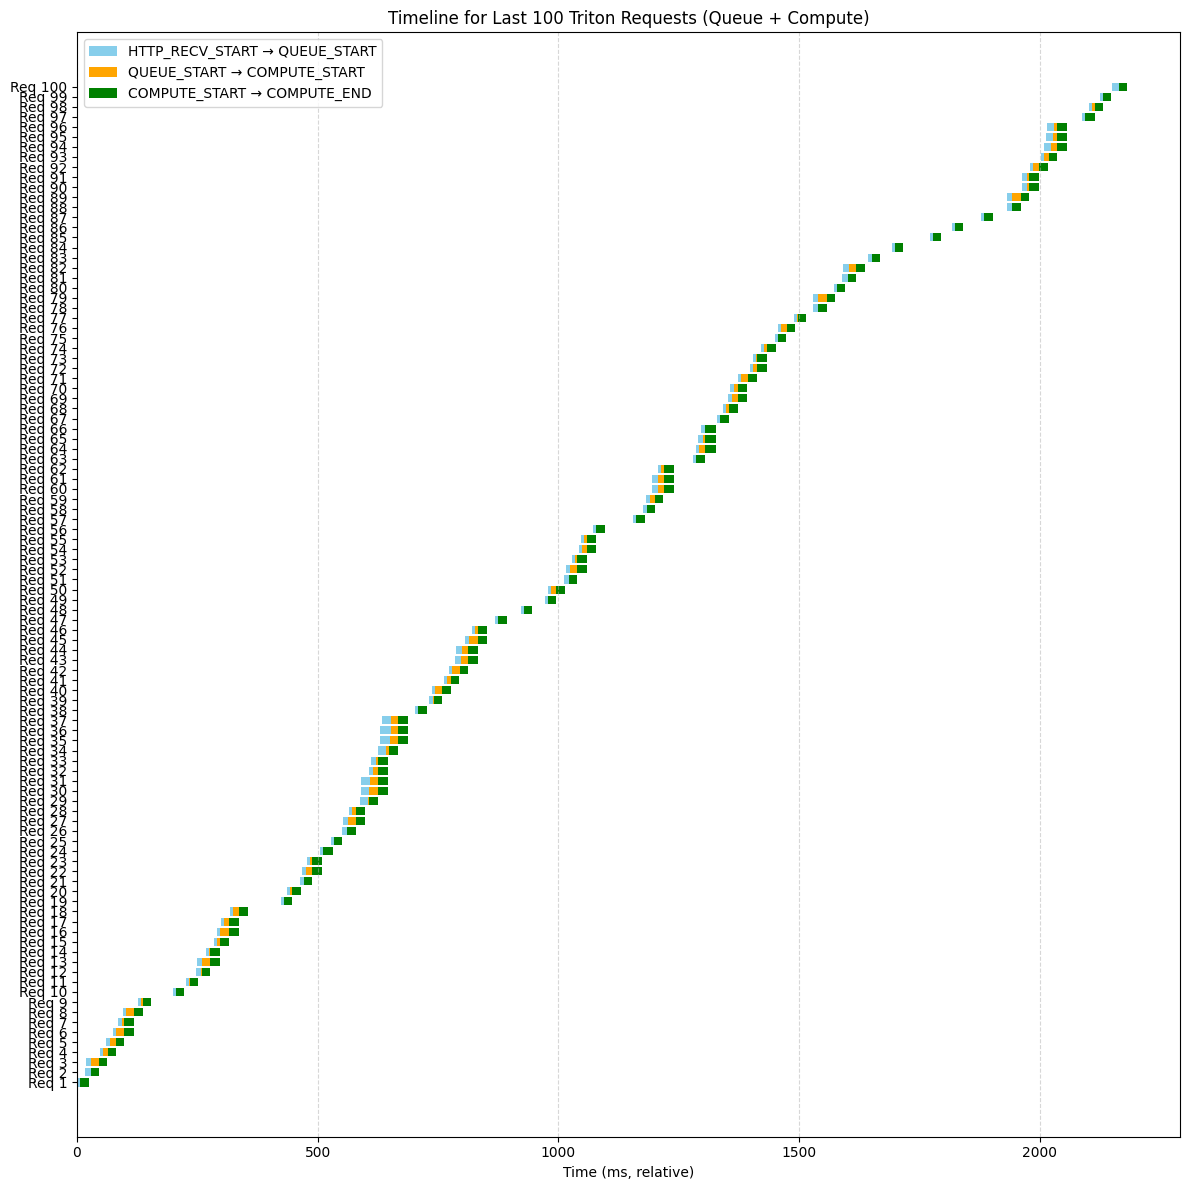

In [11]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === Load and aggregate trace ===
trace_path = "trace_test_2.json" 

with open(trace_path, "r") as f:
    entries = json.load(f)

# Aggregate by internal Triton id
by_id = {}
for e in entries:
    rid = e.get("id")
    if rid is None:
        continue
    rec = by_id.setdefault(rid, {"timestamps": {}, "meta": {}})
    for ts in e.get("timestamps", []):
        name = ts["name"]
        ns = ts["ns"]
        rec["timestamps"].setdefault(name, ns)
    for k, v in e.items():
        if k not in ["id", "timestamps"]:
            rec["meta"][k] = v

rows = []
for rid, rec in by_id.items():
    ts = rec["timestamps"]
    rows.append({
        "internal_id": rid,
        "request_id": rec["meta"].get("request_id"),
        "HTTP_RECV_START": ts.get("HTTP_RECV_START"),
        "QUEUE_START": ts.get("QUEUE_START"),
        "COMPUTE_START": ts.get("COMPUTE_START"),
        "COMPUTE_END": ts.get("COMPUTE_END"),
    })

df = pd.DataFrame(rows)

# Keep only requests that have the timestamps we need
needed = ["HTTP_RECV_START", "QUEUE_START", "COMPUTE_START", "COMPUTE_END"]
df = df.dropna(subset=needed).copy()

# Choose however many requests we want to show, from the end 
df_sorted = df.sort_values("QUEUE_START")
df_samples = df_sorted.tail(100).copy()

# Reference time for horizontal alignment
t0 = df_samples["HTTP_RECV_START"].min()

def ns_to_ms(ns):
    return (ns - t0) / 1e6

df_samples["t_http_start"] = df_samples["HTTP_RECV_START"].apply(ns_to_ms)
df_samples["t_queue_start"] = df_samples["QUEUE_START"].apply(ns_to_ms)
df_samples["t_compute_start"] = df_samples["COMPUTE_START"].apply(ns_to_ms)
df_samples["t_compute_end"] = df_samples["COMPUTE_END"].apply(ns_to_ms)

# === Plot: Gantt-style timeline for the last 100 requests ===
plt.figure(figsize=(12, 12))

y_positions = []
y_labels = []

for i, (_, row) in enumerate(df_samples.iterrows()):
    y = i
    y_positions.append(y)
    y_labels.append(f"Req {i+1}")   # ← enumerate, no request_id

    # HTTP_RECV_START → QUEUE_START
    plt.barh(y,
             row["t_queue_start"] - row["t_http_start"],
             left=row["t_http_start"],
             color="skyblue",
             label="HTTP_RECV_START → QUEUE_START" if i == 0 else None)

    # QUEUE_START → COMPUTE_START
    plt.barh(y,
             row["t_compute_start"] - row["t_queue_start"],
             left=row["t_queue_start"],
             color="orange",
             label="QUEUE_START → COMPUTE_START" if i == 0 else None)

    # COMPUTE_START → COMPUTE_END
    plt.barh(y,
             row["t_compute_end"] - row["t_compute_start"],
             left=row["t_compute_start"],
             color="green",
             label="COMPUTE_START → COMPUTE_END" if i == 0 else None)

plt.yticks(y_positions, y_labels)
plt.xlabel("Time (ms, relative)")
plt.title("Timeline for Last 100 Triton Requests (Queue + Compute)")
plt.legend(loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


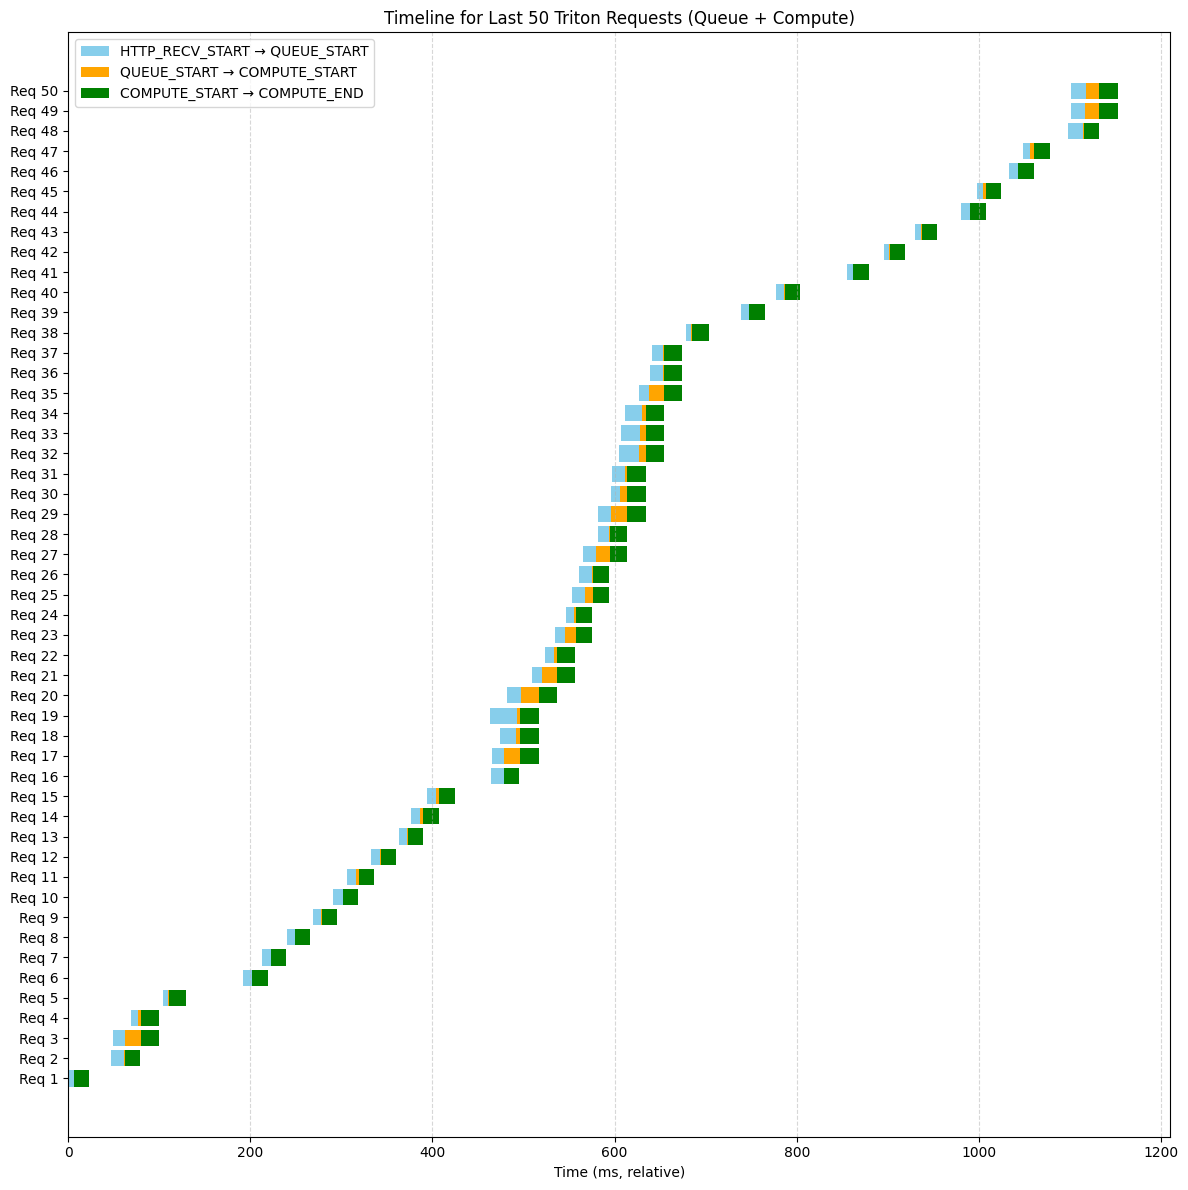

In [22]:
trace_path = "trace_test_3.json" 

with open(trace_path, "r") as f:
    entries = json.load(f)

# Aggregate by internal Triton id
by_id = {}
for e in entries:
    rid = e.get("id")
    if rid is None:
        continue
    rec = by_id.setdefault(rid, {"timestamps": {}, "meta": {}})
    for ts in e.get("timestamps", []):
        name = ts["name"]
        ns = ts["ns"]
        rec["timestamps"].setdefault(name, ns)
    for k, v in e.items():
        if k not in ["id", "timestamps"]:
            rec["meta"][k] = v

rows = []
for rid, rec in by_id.items():
    ts = rec["timestamps"]
    rows.append({
        "internal_id": rid,
        "request_id": rec["meta"].get("request_id"),
        "HTTP_RECV_START": ts.get("HTTP_RECV_START"),
        "QUEUE_START": ts.get("QUEUE_START"),
        "COMPUTE_START": ts.get("COMPUTE_START"),
        "COMPUTE_END": ts.get("COMPUTE_END"),
    })

df = pd.DataFrame(rows)

# Keep only requests that have the timestamps we need
needed = ["HTTP_RECV_START", "QUEUE_START", "COMPUTE_START", "COMPUTE_END"]
df = df.dropna(subset=needed).copy()

# Choose however many requests we want to show, from the end 
df_sorted = df.sort_values("QUEUE_START")
df_samples = df_sorted.tail(50).copy()

# Reference time for horizontal alignment
t0 = df_samples["HTTP_RECV_START"].min()

def ns_to_ms(ns):
    return (ns - t0) / 1e6

df_samples["t_http_start"] = df_samples["HTTP_RECV_START"].apply(ns_to_ms)
df_samples["t_queue_start"] = df_samples["QUEUE_START"].apply(ns_to_ms)
df_samples["t_compute_start"] = df_samples["COMPUTE_START"].apply(ns_to_ms)
df_samples["t_compute_end"] = df_samples["COMPUTE_END"].apply(ns_to_ms)

# === Plot: Gantt-style timeline for the last 100 requests ===
plt.figure(figsize=(12, 12))

y_positions = []
y_labels = []

for i, (_, row) in enumerate(df_samples.iterrows()):
    y = i
    y_positions.append(y)
    y_labels.append(f"Req {i+1}")   # ← enumerate, no request_id

    # HTTP_RECV_START → QUEUE_START
    plt.barh(y,
             row["t_queue_start"] - row["t_http_start"],
             left=row["t_http_start"],
             color="skyblue",
             label="HTTP_RECV_START → QUEUE_START" if i == 0 else None)

    # QUEUE_START → COMPUTE_START
    plt.barh(y,
             row["t_compute_start"] - row["t_queue_start"],
             left=row["t_queue_start"],
             color="orange",
             label="QUEUE_START → COMPUTE_START" if i == 0 else None)

    # COMPUTE_START → COMPUTE_END
    plt.barh(y,
             row["t_compute_end"] - row["t_compute_start"],
             left=row["t_compute_start"],
             color="green",
             label="COMPUTE_START → COMPUTE_END" if i == 0 else None)

plt.yticks(y_positions, y_labels)
plt.xlabel("Time (ms, relative)")
plt.title("Timeline for Last 50 Triton Requests (Queue + Compute)")
plt.legend(loc="upper left")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [20]:
trace_path_request_count = "trace_test_3.json" 
with open(trace_path_request_count, "r") as f:
    entries = json.load(f)

by_id = {}

for e in entries:
    iid = e.get("id")
    if iid is None:
        continue
    rec = by_id.setdefault(iid, {"meta": {}, "timestamps": {}})
    for k, v in e.items():
        if k == "timestamps":
            for ts in v:
                rec["timestamps"].setdefault(ts["name"], ts["ns"])
        elif k not in ["id"]:
            rec["meta"][k] = v

# Count unique request_ids after aggregation
unique_req_ids = { rec["meta"].get("request_id") for rec in by_id.values() }
unique_req_ids.discard(None)

print("Unique request_id count:", len(unique_req_ids))

Unique request_id count: 350
